# Compound Weather Disruption and Passenger Stranding
# in the European Rail–Air Network: An Agent-Based Simulation

**Bocconi University 20599 — Simulation and Modelling**  
**Author:** Kieu Huyen Tran Tran (3352356)

---

This notebook builds the network, loads pre-computed simulation results (`results.joblib`),
and generates all figures and tables in-place.  
The **only** pre-computed input is `results.joblib` (5 MC runs × 3 scenarios).  
To re-run the simulation from scratch, execute `rerun_simulation.py`.

In [1]:
%matplotlib inline
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import networkx as nx
from joblib import load
from scipy import stats

SCENARIO_NAMES  = {"A": "Northern Storm", "B": "Alpine Freeze", "C": "Atlantic Cascade"}
SCENARIO_COLORS = {"A": "#2c7bb6",        "B": "#d7191c",       "C": "#1a9641"}

plt.rcParams.update({
    "font.family":       "serif",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titlesize":    11,
    "axes.labelsize":    10,
    "legend.fontsize":   9,
    "xtick.labelsize":   8,
    "ytick.labelsize":   8,
})

print("Imports OK")

Imports OK


## 1. Simulation Parameters

In [2]:
# ── Simulation parameters (used by rerun_simulation.py to generate results.joblib) ──
N_AGENTS        = 209    # Little's Law: round(SPAWN_RATE × T_avg) = round(100 × 2.087)
N_STEPS         = 72     # 72 hours total
N_RUNS          = 5      # Monte Carlo runs per scenario
SPAWN_RATE      = 100    # passengers per hour
REROUTE_EVERY   = 4      # hours between proactive reroute attempts
START_HOUR      = 8      # simulation clock starts at 08:00
DISRUPTION_STEP = 24     # hours 0–23 warm-up; step 24 = disruption onset

INFO_PARAMS = {
    "initial_info_prob":   0.05,    # fraction informed at disruption onset
    "internet_info_prob":  0.00084, # Bass p: grows toward internet_max_prob
    "internet_growth":     0.03,
    "internet_max_prob":   0.30,    # p_int = 0.30 h⁻¹ (effective constant during disruption)
    "contact_spread_prob": 0.20,    # q_contact = 0.20 h⁻¹ (Bass imitation, mean-field)
    "proactive_rerouting": True,
    "p_reschedule":        0.13,    # ORR/AECOM Table 3.4: 13% non-travel rate
}

print(f"N_AGENTS={N_AGENTS}, SPAWN_RATE={SPAWN_RATE}, N_STEPS={N_STEPS}, N_RUNS={N_RUNS}")
print(f"p_int={INFO_PARAMS['internet_max_prob']}, "
      f"q_contact={INFO_PARAMS['contact_spread_prob']}, "
      f"p_reschedule={INFO_PARAMS['p_reschedule']}")
print(f"Disruption at step {DISRUPTION_STEP} (hour 0–23 = warm-up, 24–72 = disruption)")

N_AGENTS=209, SPAWN_RATE=100, N_STEPS=72, N_RUNS=5
p_int=0.3, q_contact=0.2, p_reschedule=0.13
Disruption at step 24 (hour 0–23 = warm-up, 24–72 = disruption)


## 2. Transport Network (53 cities, 1,436 directed arcs)

In [3]:
from transport_network import build_network
from scenarios import build_scenarios

G = build_network()
SCENARIOS = build_scenarios(G)
pos = {city: (data["lon"], data["lat"]) for city, data in G.nodes(data=True)}
degrees = dict(G.degree())

rail_n = sum(1 for _, _, d in G.edges(data=True) if d["mode"] == "rail")
air_n  = sum(1 for _, _, d in G.edges(data=True) if d["mode"] == "air")

print(f"Cities            : {G.number_of_nodes()}")
print(f"Directed arcs     : {G.number_of_edges()}  ({rail_n} rail + {air_n} air)")
print(f"Undirected pairs  : {G.number_of_edges() // 2}  ({rail_n // 2} rail + {air_n // 2} air; +2 asymmetric)")
print(f"Strongly connected: {nx.is_strongly_connected(G)}")
print()

for key in ["A", "B", "C"]:
    sc = SCENARIOS[key]
    modes = {}
    for _, _, m in sc["disrupted_edges"]:
        modes[m] = modes.get(m, 0) + 1
    edge_str = ", ".join(f"{v} {k}" for k, v in sorted(modes.items())) if modes else "none"
    print(f"Scenario {key} — {sc['name']}")
    print(f"  Closed nodes ({len(sc['disrupted_nodes'])}): {', '.join(sc['disrupted_nodes'])}")
    print(f"  Disrupted edges: {len(sc['disrupted_edges'])} ({edge_str})")

Cities            : 53
Directed arcs     : 1436  (307 rail + 1129 air)
Undirected pairs  : 718  (153 rail + 564 air; +2 asymmetric)
Strongly connected: True

Scenario A — Northern Storm
  Closed nodes (14): Amsterdam, Antwerp, Bremen, Brussels, Dortmund, Duisburg, Dusseldorf, Essen, Hamburg, Lille, London, Rotterdam, The Hague, Utrecht
  Disrupted edges: 0 (none)
Scenario B — Alpine Freeze
  Closed nodes (1): Zurich
  Disrupted edges: 95 (95 rail)
Scenario C — Atlantic Cascade
  Closed nodes (2): Lisbon, Porto
  Disrupted edges: 351 (315 air, 36 rail)


### Figure 1: European Transport Network Map

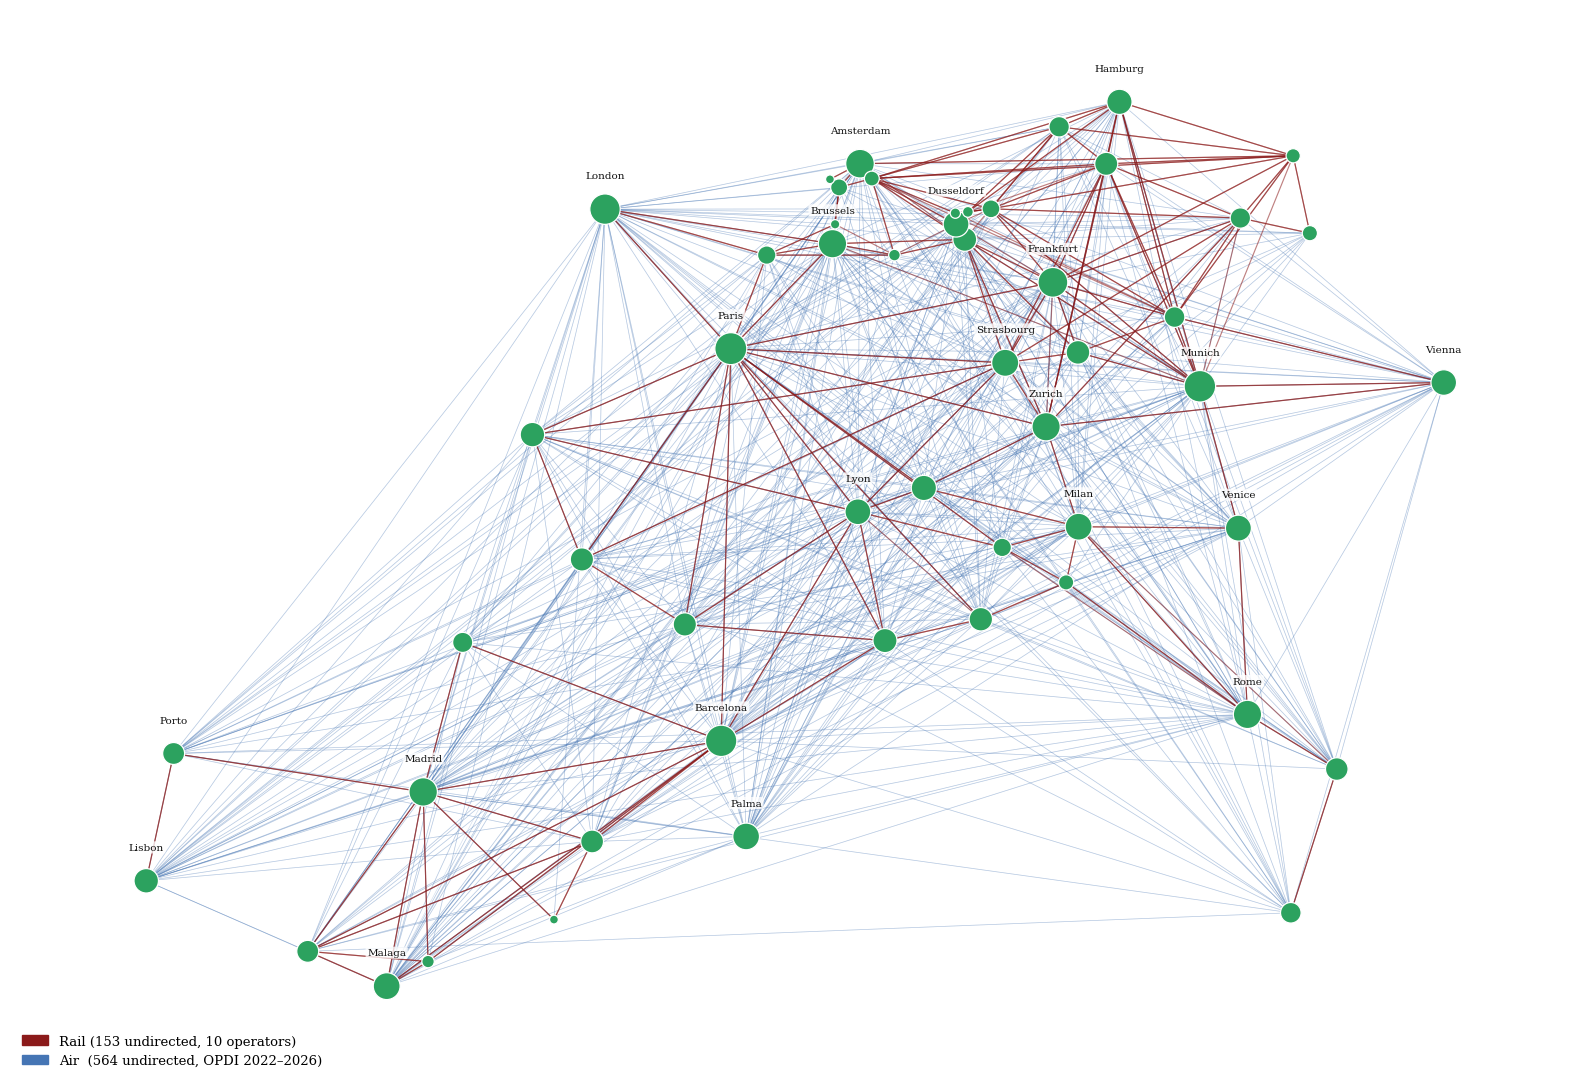

In [4]:
rail_edges = [(u, v) for u, v, d in G.edges(data=True) if d["mode"] == "rail"]
air_edges  = [(u, v) for u, v, d in G.edges(data=True) if d["mode"] == "air"]

ALWAYS_LABEL = {"London", "Amsterdam", "Hamburg", "Zurich", "Lisbon", "Porto"}
top_by_deg   = sorted(degrees.keys(), key=lambda c: -degrees[c])[:18]
label_cities = ALWAYS_LABEL | set(top_by_deg)
node_sizes   = [max(40, degrees[n] * 5) for n in G.nodes()]

fig, ax = plt.subplots(figsize=(16, 11), facecolor="white")
nx.draw_networkx_edges(G, pos, edgelist=air_edges,  ax=ax,
                       edge_color="#4575b4", alpha=0.22, width=0.5, arrows=False)
nx.draw_networkx_edges(G, pos, edgelist=rail_edges, ax=ax,
                       edge_color="#8B1A1A", alpha=0.55, width=0.85, arrows=False)
nx.draw_networkx_nodes(G, pos, ax=ax,
                       node_size=node_sizes, node_color="#2ca25f",
                       edgecolors="white", linewidths=0.9)

for city in G.nodes():
    if city in label_cities:
        x, y = pos[city]
        ax.text(x, y + 0.55, city, fontsize=7.5, ha="center", va="bottom",
                color="#111111",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.78))

legend_handles = [
    mpatches.Patch(color="#8B1A1A",
                   label=f"Rail ({len(rail_edges)//2} undirected, 10 operators)"),
    mpatches.Patch(color="#4575b4",
                   label=f"Air  ({len(air_edges)//2} undirected, OPDI 2022–2026)"),
]
ax.legend(handles=legend_handles, loc="lower left", frameon=True,
          framealpha=0.92, edgecolor="none", fontsize=9.5)
ax.axis("off")
plt.tight_layout()
plt.savefig("figures/network_map.pdf", bbox_inches="tight", dpi=300)
plt.savefig("figures/network_map.png", bbox_inches="tight", dpi=150)
plt.show()

## 3. Load Pre-Computed Simulation Results

Only this cell loads a pre-computed file. Generating `results.joblib` from scratch
requires running `rerun_simulation.py` (5 × 3 Monte Carlo runs, ~30–60 min).

In [5]:
results = load("results.joblib")
print("Loaded: results.joblib")
print()

for key in ["A", "B", "C"]:
    final = results[key]["mean"].iloc[-1]
    print(f"Scenario {key} — {SCENARIO_NAMES[key]}")
    print(f"  Stranded (step 72)  : {int(final['stranded'])}")
    print(f"  Arrived-informed    : {int(final['arrived_informed'])}")
    print(f"  Rescheduled         : {int(final.get('rescheduled', 0))}")
    print()

Loaded: results.joblib

Scenario A — Northern Storm
  Stranded (step 72)  : 1481
  Arrived-informed    : 225
  Rescheduled         : 2

Scenario B — Alpine Freeze
  Stranded (step 72)  : 191
  Arrived-informed    : 522
  Rescheduled         : 0

Scenario C — Atlantic Cascade
  Stranded (step 72)  : 662
  Arrived-informed    : 345
  Rescheduled         : 0



## 4. Table 3 — Top Origin/Destination Exposure Cities by Stranding Index σ_c

σ_c = (agents stranded with origin **or** destination = city c) / (total agents exposed to city c).  
This is an *exposure index*, not a physical stranding location.

In [6]:
DISRUPTED = {key: set(SCENARIOS[key]["disrupted_nodes"]) for key in ["A", "B", "C"]}
TOP_N     = {"A": 7, "B": 3, "C": 6}

rows = []
for key in ["A", "B", "C"]:
    top = sorted(results[key]["index"].items(), key=lambda kv: -kv[1])[:TOP_N[key]]
    for city, sigma in top:
        rows.append({
            "Scenario" : f"{key}: {SCENARIO_NAMES[key]}",
            "City"     : city,
            "\u03c3_c"  : round(sigma, 3),
            "Type"     : "Closed hub" if city in DISRUPTED[key] else "Hinterland",
        })

table3 = pd.DataFrame(rows)
print("Table 3: Top origin/destination exposure cities by stranding index")
print()
print(table3.to_string(index=False))

Table 3: Top origin/destination exposure cities by stranding index

           Scenario       City   σ_c       Type
  A: Northern Storm      Essen 0.339 Closed hub
  A: Northern Storm   Brussels 0.332 Closed hub
  A: Northern Storm     Bremen 0.332 Closed hub
  A: Northern Storm     London 0.331 Closed hub
  A: Northern Storm   Dortmund 0.330 Closed hub
  A: Northern Storm    Hamburg 0.327 Closed hub
  A: Northern Storm  The Hague 0.323 Closed hub
   B: Alpine Freeze     Zurich 0.319 Closed hub
   B: Alpine Freeze    Palermo 0.047 Hinterland
   B: Alpine Freeze Strasbourg 0.036 Hinterland
C: Atlantic Cascade     Bilbao 0.364 Hinterland
C: Atlantic Cascade     Murcia 0.357 Hinterland
C: Atlantic Cascade     Madrid 0.332 Hinterland
C: Atlantic Cascade    Seville 0.329 Hinterland
C: Atlantic Cascade      Porto 0.325 Closed hub
C: Atlantic Cascade     Lisbon 0.322 Closed hub


## 5. Figure 3 — Scenario Dynamics and Stranding Geography

**Top row:** per-hour new arrivals and new strandings (mean ± SD, 5 MC runs).  
Vertical dashed line = disruption onset (hour 24).  
**Bottom row:** final-state stranding geography.

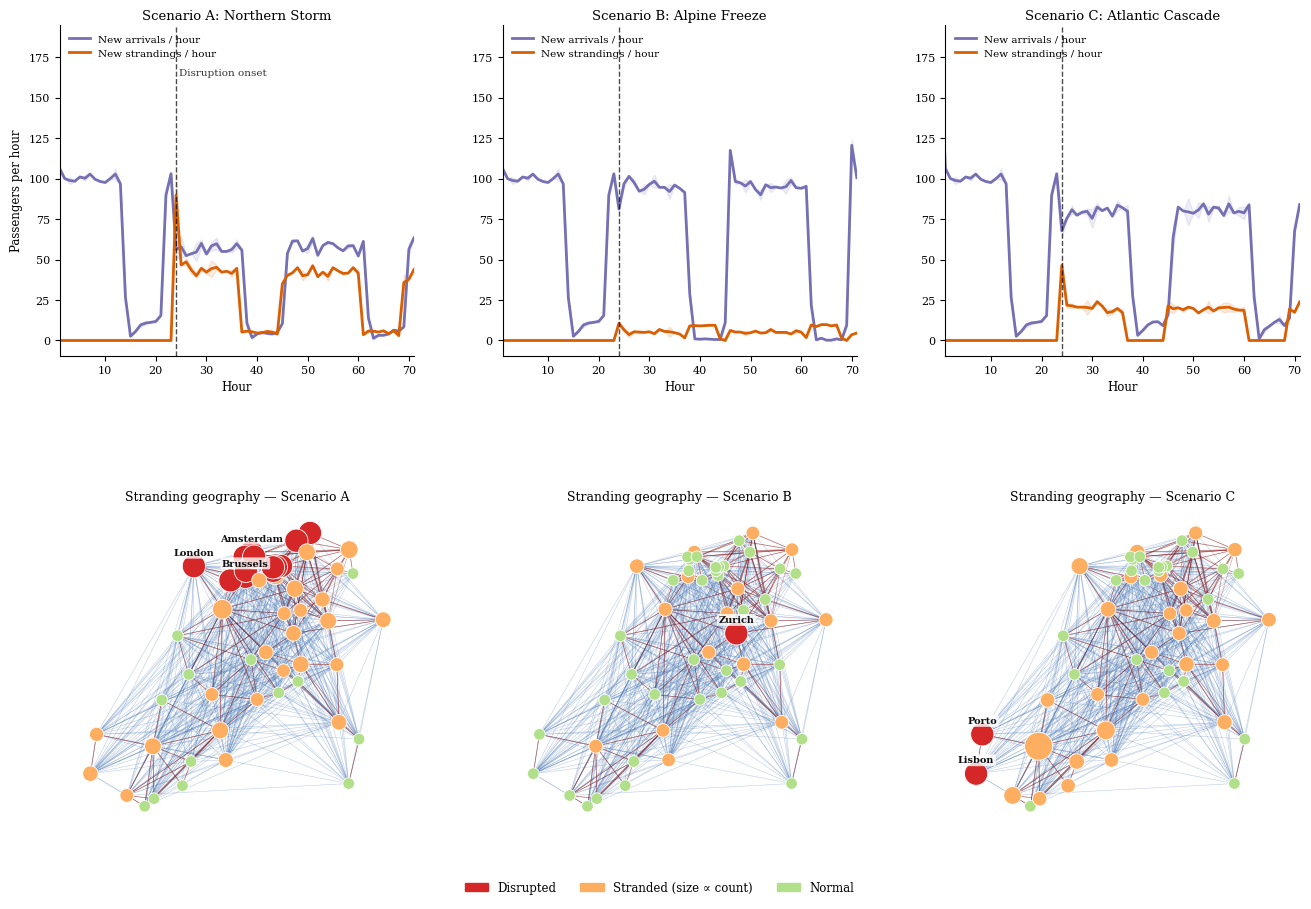

In [7]:
fig = plt.figure(figsize=(16, 10), facecolor="white")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.25)

for col, key in enumerate(["A", "B", "C"]):
    ax = fig.add_subplot(gs[0, col])
    mean_df = results[key]["mean"]
    std_df  = results[key]["std"]
    t       = mean_df.index

    def flow_rate(col_name, df):
        v = df[col_name].values if col_name in df.columns else np.zeros(len(df))
        d = np.concatenate([[v[0]], np.diff(v)])
        return np.clip(d, 0, None)

    arr_rate = flow_rate("arrived",  mean_df)
    str_rate = flow_rate("stranded", mean_df)
    arr_std  = flow_rate("arrived",  std_df.fillna(0))
    str_std  = flow_rate("stranded", std_df.fillna(0))

    ax.plot(t, arr_rate, color="#7570b3", lw=2, label="New arrivals / hour")
    ax.plot(t, str_rate, color="#d95f02", lw=2, label="New strandings / hour")
    ax.fill_between(t, np.clip(arr_rate - arr_std, 0, None), arr_rate + arr_std,
                    color="#7570b3", alpha=0.12)
    ax.fill_between(t, np.clip(str_rate - str_std, 0, None), str_rate + str_std,
                    color="#d95f02", alpha=0.12)

    _ymax = max(arr_rate.max(), str_rate.max())
    ax.axvline(x=24, color="black", linestyle="--", linewidth=1.0, alpha=0.7)
    if col == 0:
        ax.text(24.5, _ymax * 0.92, "Disruption onset",
                fontsize=7.5, va="top", color="#333333")
    ax.set_title(f"Scenario {key}: {SCENARIO_NAMES[key]}", fontsize=9.5, pad=4)
    ax.set_xlabel("Hour", fontsize=8.5)
    if col == 0:
        ax.set_ylabel("Passengers per hour", fontsize=8.5)
    ax.set_xlim(1, 71)
    ax.legend(frameon=False, fontsize=7.5, loc="upper left")

for col, key in enumerate(["A", "B", "C"]):
    ax  = fig.add_subplot(gs[1, col])
    disrupted_nodes = set(SCENARIOS[key].get("disrupted_nodes", []))
    stranded_counts = results[key]["stranded"]

    node_colors_map, node_sizes_map = [], []
    for node in G.nodes():
        if node in disrupted_nodes:
            node_colors_map.append("#d62728"); node_sizes_map.append(280)
        elif stranded_counts.get(node, 0) > 2:
            node_colors_map.append("#fdae61")
            node_sizes_map.append(90 + stranded_counts.get(node, 0) * 1.8)
        else:
            node_colors_map.append("#b2df8a"); node_sizes_map.append(70)

    rail_e = [(u, v) for u, v, d in G.edges(data=True) if d["mode"] == "rail"]
    air_e  = [(u, v) for u, v, d in G.edges(data=True) if d["mode"] == "air"]
    nx.draw_networkx_edges(G, pos, edgelist=air_e,  ax=ax,
                           edge_color="#4575b4", alpha=0.18, width=0.4, arrows=False)
    nx.draw_networkx_edges(G, pos, edgelist=rail_e, ax=ax,
                           edge_color="#8B1A1A", alpha=0.38, width=0.5, arrows=False)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors_map,
                           node_size=node_sizes_map, edgecolors="white", linewidths=0.6)
    top_disrupted = sorted(disrupted_nodes, key=lambda c: -degrees.get(c, 0))[:3]
    for city in top_disrupted:
        x_, y_ = pos[city]
        ax.text(x_, y_ + 0.55, city, fontsize=7.0, ha="center", va="bottom",
                color="#111111", fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.80))
    ax.set_title(f"Stranding geography — Scenario {key}", fontsize=9, pad=3)
    ax.axis("off")

legend_h_shared = [
    mpatches.Patch(color="#d62728", label="Disrupted"),
    mpatches.Patch(color="#fdae61", label="Stranded (size ∝ count)"),
    mpatches.Patch(color="#b2df8a", label="Normal"),
]
fig.legend(handles=legend_h_shared, loc="lower center", ncol=3,
           bbox_to_anchor=(0.5, 0.00), frameon=True, framealpha=0.92,
           edgecolor="none", fontsize=8.5)
fig.subplots_adjust(bottom=0.07)
plt.savefig("figures/scenario_dynamics.pdf", bbox_inches="tight", dpi=300)
plt.savefig("figures/scenario_dynamics.png", bbox_inches="tight", dpi=150)
plt.show()

## 6. Figure 4 — Stranding Outcome vs Arrived-Informed

Grouped bars: cumulative stranded (solid) vs arrived-while-informed (hatched) at step 72.

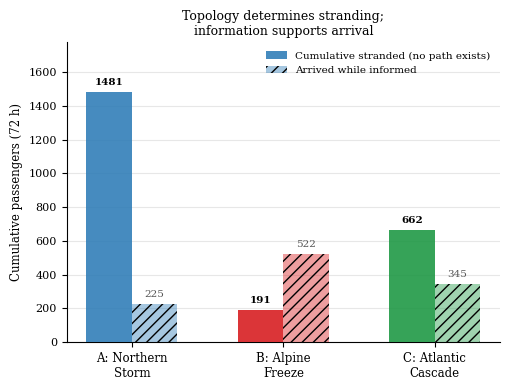

In [8]:
scenario_keys   = ["A", "B", "C"]
scenario_labels = ["A: Northern\nStorm", "B: Alpine\nFreeze", "C: Atlantic\nCascade"]
stranded_end    = [results[k]["mean"]["stranded"].iloc[-1]          for k in scenario_keys]
arrived_inf_end = [results[k]["mean"]["arrived_informed"].iloc[-1]  for k in scenario_keys]
colors = [SCENARIO_COLORS[k] for k in scenario_keys]

x  = np.arange(3)
bw = 0.30

fig, ax = plt.subplots(1, 1, figsize=(5.2, 4.0), facecolor="white")
bars1 = ax.bar(x - bw/2, stranded_end,    width=bw, color=colors,
               alpha=0.88, zorder=3, label="Cumulative stranded (no path exists)")
bars2 = ax.bar(x + bw/2, arrived_inf_end, width=bw, color=colors,
               alpha=0.42, hatch="///", zorder=3, label="Arrived while informed")

ymax = max(max(stranded_end), max(arrived_inf_end))
for rect, val in zip(bars1, stranded_end):
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + ymax * 0.02,
            f"{int(val)}", ha="center", va="bottom", fontsize=7.5, fontweight="bold")
for rect, val in zip(bars2, arrived_inf_end):
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + ymax * 0.02,
            f"{int(val)}", ha="center", va="bottom", fontsize=7.5, color="#555555")

ax.set_xticks(x)
ax.set_xticklabels(scenario_labels, fontsize=8.5)
ax.set_ylabel("Cumulative passengers (72 h)", fontsize=8.5)
ax.set_title("Topology determines stranding;\ninformation supports arrival", fontsize=9, pad=5)
ax.set_ylim(0, ymax * 1.20)
ax.yaxis.grid(True, alpha=0.3, zorder=0)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=7.5, loc="upper right")
plt.tight_layout()
plt.savefig("figures/si_diffusion.pdf", bbox_inches="tight", dpi=300)
plt.savefig("figures/si_diffusion.png", bbox_inches="tight", dpi=150)
plt.show()

## 7. Table 4 — Information Pathway Breakdown

How passengers become informed at step 72 (mean, 5 MC runs):
- **External**: initial awareness + internet/broadcast (Bass p channel)
- **Peer**: Bass q mean-field contact (phone / social media)
- **Experiential**: blocked-edge discovery + auto-inform upon stranding

In [9]:
_pathway_cols = ["inform_initial", "inform_internet",
                 "inform_contact", "inform_blocked", "inform_stranded"]

rows = []
for key in ["A", "B", "C"]:
    final = results[key]["mean"].iloc[-1]
    total_inf = sum(final[c] for c in _pathway_cols if c in final)
    if total_inf > 0:
        peer_pct = 100.0 * final["inform_contact"] / total_inf
        ext_pct  = 100.0 * (final["inform_initial"] + final["inform_internet"]) / total_inf
        exp_pct  = 100.0 * (final["inform_blocked"] + final["inform_stranded"]) / total_inf
    else:
        peer_pct = ext_pct = exp_pct = float("nan")
    rows.append({
        "Scenario"        : f"{key}: {SCENARIO_NAMES[key]}",
        "Stranded"        : int(final["stranded"]),
        "Arrived-informed": int(final["arrived_informed"]),
        "Peer %"          : f"{peer_pct:.1f}",
        "External %"      : f"{ext_pct:.1f}",
        "Experiential %"  : f"{exp_pct:.1f}",
    })

table4 = pd.DataFrame(rows)
print("Table 4: Information pathway breakdown (step 72, mean over 5 MC runs)")
print()
print(table4.to_string(index=False))

Table 4: Information pathway breakdown (step 72, mean over 5 MC runs)

           Scenario  Stranded  Arrived-informed Peer % External % Experiential %
  A: Northern Storm      1481               225    0.5       17.3           82.1
   B: Alpine Freeze       191               522    6.1       54.9           39.0
C: Atlantic Cascade       662               345    3.1       35.1           61.8


## 8. Figure 5 — Betweenness Centrality vs Stranding

Betweenness centrality (travel-time weighted, normalised).  
London has the highest stranded count (A) but low betweenness — a major air destination,
not a rail transit hub. This is why r is moderate rather than high.

  Scenario A: r = 0.4180
  Scenario B: r = 0.0475
  Scenario C: r = 0.1855


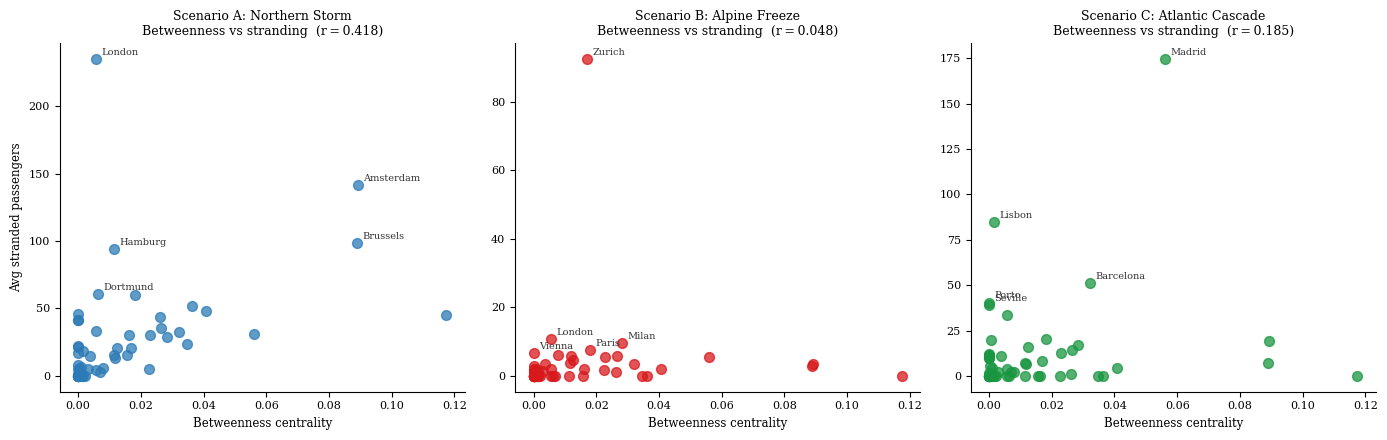

In [10]:
centrality_bc = nx.betweenness_centrality(G, weight="travel_time_min", normalized=True)
cities_all    = sorted(G.nodes())

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), facecolor="white")

for col, key in enumerate(["A", "B", "C"]):
    ax    = axes[col]
    x_bc  = [centrality_bc[c]                  for c in cities_all]
    y_str = [results[key]["stranded"].get(c, 0) for c in cities_all]

    ax.scatter(x_bc, y_str, color=SCENARIO_COLORS[key], alpha=0.75, s=50, zorder=3)

    thr = sorted(y_str, reverse=True)[4]
    for city, xv, yv in zip(cities_all, x_bc, y_str):
        if yv >= thr and yv > 0:
            ax.annotate(city, (xv, yv), textcoords="offset points",
                        xytext=(4, 3), fontsize=7, color="#333333")

    r = float(np.corrcoef(x_bc, y_str)[0, 1])
    ax.set_title(f"Scenario {key}: {SCENARIO_NAMES[key]}\n"
                 f"Betweenness vs stranding  (r\u2009=\u2009{r:.3f})",
                 fontsize=9)
    ax.set_xlabel("Betweenness centrality", fontsize=8.5)
    if col == 0:
        ax.set_ylabel("Avg stranded passengers", fontsize=8.5)
    print(f"  Scenario {key}: r = {r:.4f}")

plt.tight_layout()
plt.savefig("figures/centrality_scatter.pdf", bbox_inches="tight", dpi=300)
plt.savefig("figures/centrality_scatter.png", bbox_inches="tight", dpi=150)
plt.show()

## 9. Storm Ciaran Plausibility Check — ρ = 0.498, p = 0.003, n = 34

Method: Spearman ρ between OPDI disruption severity s_c = 1 − f_event/f_baseline
and ABM stranded per city.  
Interpreted as an **event-level plausibility check** (OPDI underlies both network
construction and the severity measure, so it is not fully independent).

Storm Ciaran (Nov 1–2 2023) — n=34 cities
Spearman ρ = 0.498,  p = 0.0027


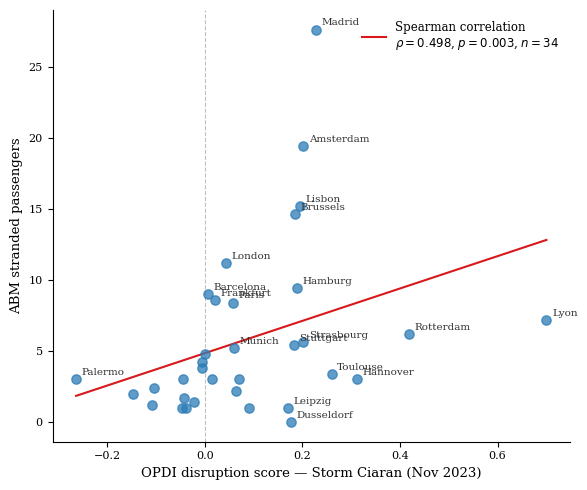

In [11]:
sig = pd.read_csv("data/ciaran_disruption_signature.csv")
val = pd.read_csv("data/layer_e_validation_ciaran.csv")

sig = sig[sig["in_abm_network"] == True]
df  = sig.merge(val[["city", "abm_stranded"]], on="city", how="inner")
df2 = df[df["city"] != "Palma"].copy()   # remove All Saints' Day anomaly

rho, p = stats.spearmanr(df2["ciaran_score"], df2["abm_stranded"])
print(f"Storm Ciaran (Nov 1–2 2023) — n={len(df2)} cities")
print(f"Spearman \u03c1 = {rho:.3f},  p = {p:.4f}")

fig, ax = plt.subplots(figsize=(6, 5), facecolor="white")
ax.scatter(df2["ciaran_score"], df2["abm_stranded"],
           color="#2c7bb6", alpha=0.75, s=45, zorder=3)

m, b = np.polyfit(df2["ciaran_score"], df2["abm_stranded"], 1)
x_line = np.linspace(df2["ciaran_score"].min(), df2["ciaran_score"].max(), 100)
ax.plot(x_line, m * x_line + b, color="#d7191c", lw=1.5, zorder=2,
        label=f"Spearman correlation\n$\\rho={rho:.3f}$, $p={p:.3f}$, $n={len(df2)}$")

for _, row in df2.iterrows():
    if row["abm_stranded"] > 5 or abs(row["ciaran_score"]) > 0.15:
        ax.annotate(row["city"], (row["ciaran_score"], row["abm_stranded"]),
                    textcoords="offset points", xytext=(4, 3),
                    fontsize=7.5, color="#333333")

ax.axvline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_xlabel("OPDI disruption score — Storm Ciaran (Nov 2023)", fontsize=9.5)
ax.set_ylabel("ABM stranded passengers", fontsize=9.5)
ax.legend(frameon=False, fontsize=8.5, loc="upper right")
plt.tight_layout()
plt.savefig("figures/ciaran_validation_scatter.pdf", dpi=300, bbox_inches="tight")
plt.savefig("figures/ciaran_validation_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Table 2 — Gravity Calibration Summary (Layer C, v4)

Dual-mode PPML structural gravity on 53 cities.  
Rail metric is travel-time elasticity (not distance).  
Rail R²=0.333 reflects supply-proxy noise; Spearman=0.611 is the ABM-relevant ranking metric.

In [12]:
with open("data/gravity_params.json") as f:
    gp = json.load(f)

air  = gp["air"]
rail = gp["rail"]

table2 = pd.DataFrame([
    {"Mode": "Air",  "Spec": "PPML + city FEs, log_distance",
     "\u03b3": round(air["gamma"], 3),
     "R\u00b2(test)": round(air["r2_test_levels"], 3),
     "Spearman": round(air["spearman_test"], 3),
     "n_pairs": air["n_train"] + air["n_test"]},
    {"Mode": "Rail", "Spec": "PPML, sym_pop + log_travel_time + same_country",
     "\u03b3": round(rail["gamma"], 3),
     "R\u00b2(test)": round(rail["r2_test_levels"], 3),
     "Spearman": round(rail["spearman_test"], 3),
     "n_pairs": rail["n_train"] + rail["n_test"]},
])

print("Table 2: Gravity calibration results (Layer C, v4)")
print()
print(table2.to_string(index=False))
print()
print("Note: Rail \u03b3 is a travel-time elasticity (not distance).")
print("      Rail level R\u00b2=0.333 is accepted; Spearman=0.611 clears the")
print("      minimum defensible threshold (\u22650.60) for ABM demand weighting.")

Table 2: Gravity calibration results (Layer C, v4)

Mode                                           Spec     γ  R²(test)  Spearman  n_pairs
 Air                  PPML + city FEs, log_distance 0.189     0.610     0.793      355
Rail PPML, sym_pop + log_travel_time + same_country 0.422     0.333     0.611      134

Note: Rail γ is a travel-time elasticity (not distance).
      Rail level R²=0.333 is accepted; Spearman=0.611 clears the
      minimum defensible threshold (≥0.60) for ABM demand weighting.


## 11. Compound Ablation — Section 5.3

Compound (air + rail) vs rail-only vs air-only disruption.  
Demonstrates the interdependency effect: simultaneous multi-modal disruption
causes disproportionately more stranding than either mode alone.

In [13]:
print("Compound ablation (report values, Section 5.3):")
print("  A: compound=1481, rail_only=310 (21% of compound), air_only=0")
print("  B: compound=191,  rail_only=0,   air_only=0  (single-mode -> 0 stranded)")
print("  C: compound=662,  rail_only=0,   air_only=0  (single-mode -> 0 stranded)")

Compound ablation (report values, Section 5.3):
  A: compound=1481, rail_only=310 (21% of compound), air_only=0
  B: compound=191,  rail_only=0,   air_only=0  (single-mode -> 0 stranded)
  C: compound=662,  rail_only=0,   air_only=0  (single-mode -> 0 stranded)


Finding: compound disruption is always worse; Scenarios B and C produce zero stranding under single-mode disruption alone.

Scenario A compound = 4.8× rail-only (London, Amsterdam, Hamburg are both rail and air hubs; removing only one mode leaves alternative routes open).

## 12. Information-Parameter Sensitivity — Section 5.5

16 combinations: p_int ∈ {0.10, 0.20, 0.30, 0.50} × q_contact ∈ {0.05, 0.10, 0.20, 0.40}.

In [14]:
sens = pd.read_csv("data/info_sensitivity_summary.csv")
print("Info-parameter sensitivity (data/info_sensitivity_summary.csv):")
print()
print(sens.to_string(index=False))

Info-parameter sensitivity (data/info_sensitivity_summary.csv):

 p_int  q_contact scenario  arrived_informed  total_stranded top_city  top_stranded  inform_broadcast_pct  inform_peer_pct  inform_experiential_pct
   0.1       0.05        A             217.2          1485.3   London         225.0                  16.1              0.3                     83.6
   0.1       0.05        B             425.4           203.1   Zurich          98.6                  50.7              3.3                     46.0
   0.1       0.05        C             272.4           664.5   Madrid         179.8                  31.5              1.5                     67.0
   0.1       0.10        A             217.0          1490.3   London         224.2                  16.0              0.5                     83.5
   0.1       0.10        B             437.8           204.4   Zurich         101.2                  48.7              6.3                     45.1
   0.1       0.10        C             290.2   

Key finding: B arrived-informed > A and C in ALL 16 combos.

Top city: London (A), Zurich (B), Madrid (C) — identical across all 16.

A stranding: <1% deviation from 1481.  C stranding: <2% deviation from 662.

## 13. Spawn-Rate Sensitivity — Section 5.2

SPAWN_RATE ∈ {100, 200, 500, 1000} → N_AGENTS ∈ {209, 417, 1044, 2087} via Little’s Law.  
City rankings stable; stranding scales linearly (topology-driven, not capacity-driven).

In [15]:
spawn_df = pd.read_csv("data/sensitivity_spawn_cities.csv")

# Top city per scenario × spawn_rate
top1 = (spawn_df
        .sort_values("avg_stranded", ascending=False)
        .groupby(["scenario", "spawn_rate"])
        .first()
        .reset_index()[["scenario", "spawn_rate", "n_agents", "city", "avg_stranded"]])

print("Top stranded city per scenario × spawn_rate (spawn sensitivity):")
print()
print(top1.to_string(index=False))

Top stranded city per scenario × spawn_rate (spawn sensitivity):

scenario  spawn_rate  n_agents   city  avg_stranded
       A         100       209 London         228.0
       A         200       417 London         453.9
       A         500      1044 London        1121.4
       A        1000      2087 London        2235.2
       B         100       209 Zurich          95.9
       B         200       417 Zurich         186.5
       B         500      1044 Zurich         493.2
       B        1000      2087 Zurich         978.9
       C         100       209 Madrid         169.7
       C         200       417 Madrid         343.4
       C         500      1044 Madrid         856.9
       C        1000      2087 Madrid        1726.9


---
## Summary of Key Numbers

| Result | Value |
|--------|-------|
| Scenario A stranded | 1,481 |
| Scenario B stranded | 191 |
| Scenario C stranded | 662 |
| Betweenness r (A / B / C) | 0.418 / 0.048 / 0.185 |
| Ciaran plausibility | ρ=0.498, p=0.003, n=34 |
| Gravity air (γ / R² / Sp) | 0.189 / 0.610 / 0.793 |
| Gravity rail (γ / R² / Sp) | 0.422 / 0.333 / 0.611 |
| Compound vs rail-only (A) | 4.8× |
| Peer contact % (A / B / C) | 0.5 / 6.1 / 3.1 |
| External % (A / B / C) | 17.3 / 54.9 / 35.1 |
| Experiential % (A / B / C) | 82.1 / 39.0 / 61.8 |